In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('classification_dataset_10000x10.csv')

In [3]:
df.head()

,num_0,num_1,num_2,cat_3,cat_4,cat_5,ord_6,ord_7,bin_8,bin_9,target
0,4.967142,5.629107,-19.941021,C,D,B,Low,Medium,1.0,0.0,0
1,-1.382643,-1.074449,6.238354,B,D,A,High,Medium,0.0,0.0,0
2,6.476885,-0.768654,8.077358,A,B,C,Low,High,0.0,1.0,1
3,15.230299,13.134732,11.487314,D,C,A,Medium,High,1.0,1.0,1
4,-2.341534,-6.964611,0.090124,A,D,B,NaN,High,1.0,0.0,0


In [4]:
df.shape

(10000, 11)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

num_0     100
num_1      99
num_2      98
cat_3      99
cat_4     100
cat_5     100
ord_6     100
ord_7     100
bin_8     100
bin_9      99
target      0
dtype: int64

<Axes: xlabel='num_2', ylabel='Count'>

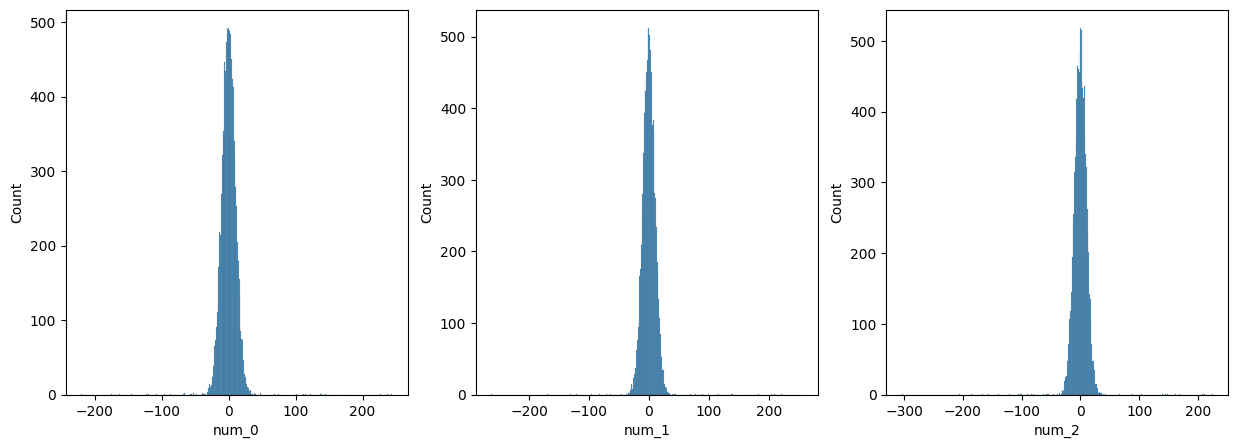

In [7]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.histplot(df['num_0'])

plt.subplot(1,3,2)
sns.histplot(df['num_1'])

plt.subplot(1,3,3)
sns.histplot(df['num_2'])

<Axes: xlabel='bin_9', ylabel='Count'>

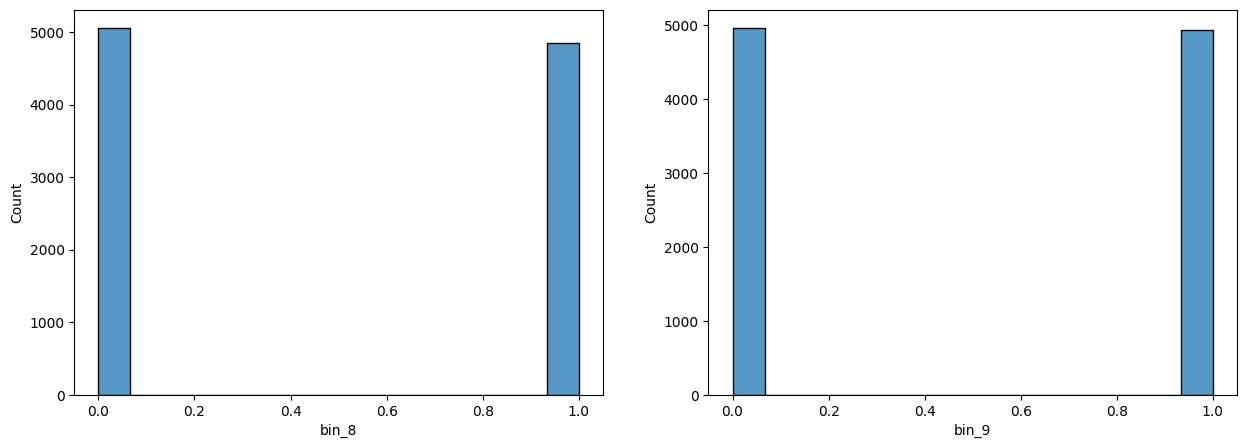

In [8]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df['bin_8'])

plt.subplot(1,2,2)
sns.histplot(df['bin_9'])


In [9]:
df['num_0']=df['num_0'].fillna(df['num_0'].mean())
df['num_1']=df['num_1'].fillna(df['num_1'].mean())
df['num_2']=df['num_2'].fillna(df['num_2'].mean())

df['cat_3']=df['cat_3'].fillna(df['cat_3'].mode()[0])
df['cat_4']=df['cat_4'].fillna(df['cat_4'].mode()[0])
df['cat_5']=df['cat_5'].fillna(df['cat_5'].mode()[0])
df['ord_6']=df['ord_6'].fillna(df['ord_6'].mode()[0])
df['ord_7']=df['ord_7'].fillna(df['ord_7'].mode()[0])

df['bin_8']=df['bin_8'].fillna(df['bin_8'].median())
df['bin_9']=df['bin_9'].fillna(df['bin_9'].median())

In [10]:
df.isna().sum()

num_0     0
num_1     0
num_2     0
cat_3     0
cat_4     0
cat_5     0
ord_6     0
ord_7     0
bin_8     0
bin_9     0
target    0
dtype: int64

In [11]:
df['bin_8'] = df['bin_8'].astype(int)
df['bin_9'] = df['bin_9'].astype(int)

print(df['bin_8'].unique())
print(df['bin_9'].unique())

[1 0]
[0 1]


In [12]:
df.dtypes

num_0     float64
num_1     float64
num_2     float64
cat_3      object
cat_4      object
cat_5      object
ord_6      object
ord_7      object
bin_8       int64
bin_9       int64
target      int64
dtype: object

In [13]:
numeric_features = [feature for feature in df.columns if df[feature].dtype!='O']
categorical_features = [feature for feature in df.columns if df[feature].dtype=='O']

print(numeric_features)
print(categorical_features)

['num_0', 'num_1', 'num_2', 'bin_8', 'bin_9', 'target']
['cat_3', 'cat_4', 'cat_5', 'ord_6', 'ord_7']


<Axes: xlabel='num_2'>

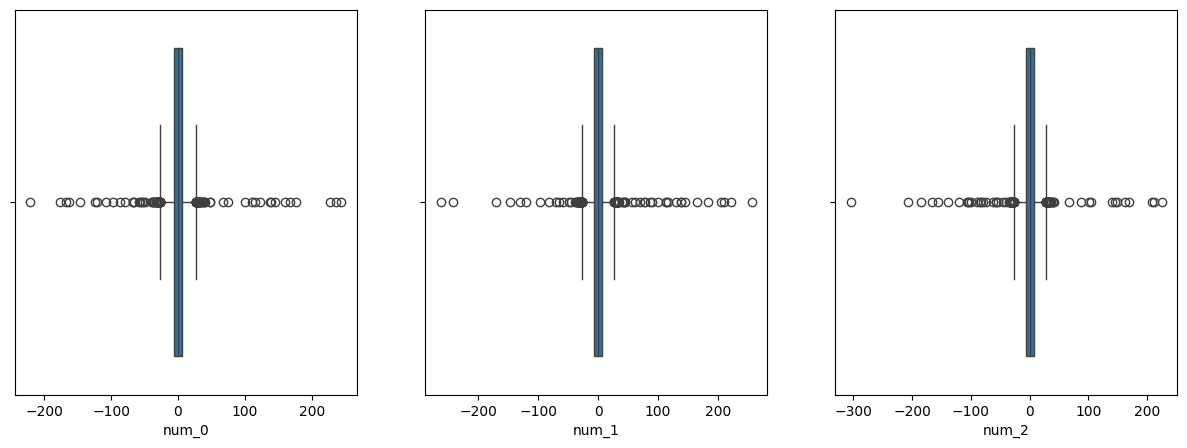

In [14]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data=df,x='num_0')

plt.subplot(1,3,2)
sns.boxplot(data=df,x='num_1')

plt.subplot(1,3,3)
sns.boxplot(data=df,x='num_2')

In [15]:
for i in numeric_features:
    Q1 = df[numeric_features].quantile(0.25)
    Q2 = df[numeric_features].median()
    Q3 = df[numeric_features].quantile(0.75)

    IQR = Q3-Q1
    lower_range = Q1 - (1.5 * IQR)
    higher_range = Q3 + (1.5 * IQR)

    df[numeric_features] = df[numeric_features].clip(lower=lower_range,upper=higher_range,axis=1)

In [16]:
df.head()

,num_0,num_1,num_2,cat_3,cat_4,cat_5,ord_6,ord_7,bin_8,bin_9,target
0,4.967142,5.629107,-19.941021,C,D,B,Low,Medium,1,0,0
1,-1.382643,-1.074449,6.238354,B,D,A,High,Medium,0,0,0
2,6.476885,-0.768654,8.077358,A,B,C,Low,High,0,1,1
3,15.230299,13.134732,11.487314,D,C,A,Medium,High,1,1,1
4,-2.341534,-6.964611,0.090124,A,D,B,Medium,High,1,0,0


In [17]:
df.shape

(10000, 11)

<Axes: xlabel='num_2'>

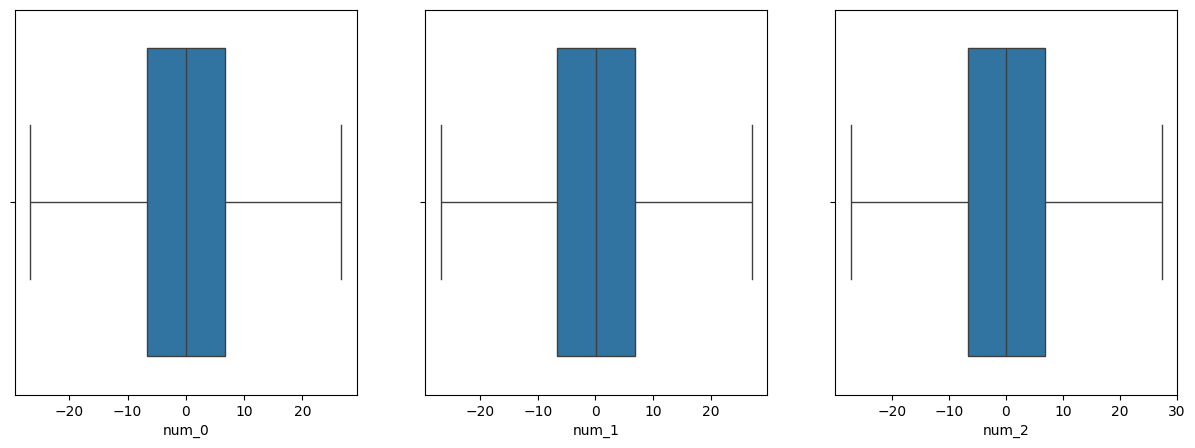

In [18]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(data=df,x='num_0')

plt.subplot(1,3,2)
sns.boxplot(data=df,x='num_1')

plt.subplot(1,3,3)
sns.boxplot(data=df,x='num_2')

In [19]:
X=df.drop('target',axis=1)
y=df['target']

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

ordinal_features = ['ord_6','ord_7']
nominal_features = [col for col in cat_features if col not in ordinal_features]

print(ordinal_features)
print(nominal_features)

['ord_6', 'ord_7']
['cat_3', 'cat_4', 'cat_5']


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

ohe = OneHotEncoder()
oe = OrdinalEncoder()
scaler = StandardScaler()

preprocessor = ColumnTransformer([
                ('ohe',ohe,nominal_features),
                ('oe',oe,ordinal_features),
                ],remainder='passthrough')

In [23]:
X_train=preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(kernel='poly')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.513
